# Principal Component Analysis (PCA) – Complete Python Practical Notebook

## Learning Objectives

By the end of this notebook, students will be able to:

- Understand dimensionality and dimensionality reduction.
- Understand why PCA is required.
- Understand variance, covariance, eigenvectors, and eigenvalues.
- Understand Principal Components.
- Understand Explained Variance and Explained Variance Ratio.
- Apply feature scaling before PCA.
- Implement PCA using Scikit-Learn.
- Select the number of Principal Components.
- Visualize high-dimensional data in 2 dimensions.
- Use PCA before a Machine Learning model.
- Understand the advantages, limitations, and common mistakes of PCA.

---

## 1. What is PCA?

**Principal Component Analysis (PCA)** is an **unsupervised dimensionality reduction technique**.

PCA transforms the original features into a new set of features called **Principal Components**.

The Principal Components:

- Are linear combinations of the original features.
- Are mutually orthogonal.
- Are ordered according to the amount of variance they explain.

### Simple Definition

**PCA reduces the number of features while trying to preserve as much information or variance as possible.**

### Example

Suppose a dataset contains:

`10 original features`

After PCA, we may represent the data using:

`3 Principal Components`

The goal is:

`10 Features → PCA → 3 Principal Components`

The reduced data may still preserve most of the important variation in the original dataset.


## 2. What is Dimensionality?

The number of input features in a dataset is commonly called its **dimensionality**.

Example:

| Feature | Description |
|---|---|
| Age | Customer age |
| Salary | Annual salary |
| Experience | Years of experience |
| Spending Score | Customer spending behavior |

The dataset contains **4 input features**.

Therefore:

**Dimensionality = 4**

A dataset with 100 input features has 100 dimensions.

---

## 3. What is Dimensionality Reduction?

Dimensionality Reduction means reducing the number of input dimensions while preserving useful information.

### Before Reduction

`X1, X2, X3, X4, X5, X6`

### After Reduction

`PC1, PC2`

### Why Reduce Dimensions?

- Reduce computational complexity.
- Reduce storage requirements.
- Remove redundant information.
- Handle highly correlated features.
- Support visualization.
- Sometimes improve model training efficiency.
- Reduce some effects of the Curse of Dimensionality.

**Important:** Dimensionality reduction does not automatically improve model accuracy. The result must be evaluated.


## 4. Why is PCA Required?

Consider a dataset containing:

- Height in centimeters
- Height in meters

These two features contain nearly the same information.

Similarly:

- Annual salary
- Monthly salary

may be strongly related.

When multiple features contain overlapping information, the dataset may contain **redundancy**.

PCA creates new directions that summarize variation in the data.

### PCA Objective

PCA tries to find directions with maximum variance.

The first direction is called:

**Principal Component 1 – PC1**

The next orthogonal direction with the highest remaining variance is:

**Principal Component 2 – PC2**

Then:

**PC3, PC4, ...**

### Ordering

`PC1 explains the most variance`

`PC2 explains the next highest variance`

`PC3 explains the next highest variance`

and so on.


## 5. Important PCA Terminology

### Variance

Variance measures how much values spread around their mean.

Higher variance means greater spread.

### Covariance

Covariance measures how two variables vary together.

- Positive covariance → Variables tend to move in the same direction.
- Negative covariance → Variables tend to move in opposite directions.
- Covariance near zero → Weak linear co-movement.

### Principal Component

A Principal Component is a new axis or direction created as a linear combination of the original features.

### Eigenvector

In PCA, eigenvectors of the covariance matrix identify important directions in the feature space.

### Eigenvalue

The corresponding eigenvalue indicates the amount of variance associated with an eigenvector direction.

### Explained Variance Ratio

The Explained Variance Ratio represents the proportion of total variance explained by each Principal Component.

Example:

- PC1 = 70%
- PC2 = 20%
- PC3 = 10%

Then:

`PC1 + PC2 = 90% of total variance`


## 6. PCA Mathematical Flow

The conceptual PCA process is:

1. Prepare the numerical feature matrix.
2. Center the features.
3. Usually standardize features when their scales differ.
4. Calculate the covariance matrix.
5. Calculate eigenvalues and eigenvectors.
6. Sort directions according to eigenvalues.
7. Select the top Principal Components.
8. Project the data onto the selected directions.

### Projection Idea

The original data is represented using original feature axes.

PCA rotates the coordinate system to new axes that capture maximum variance.

### Important Formula

A Principal Component can be represented conceptually as:

$$PC_1 = w_1X_1 + w_2X_2 + \cdots + w_nX_n$$

The values $w_1, w_2, \ldots, w_n$ are called **loadings** or component weights.


## 7. Import Required Libraries

The notebook uses:

- `NumPy` for numerical operations.
- `Pandas` for tabular data.
- `Matplotlib` for visualization.
- `Scikit-Learn` for scaling, PCA, datasets, model training, and evaluation.


In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PCA implementation from Scikit-Learn
from sklearn.decomposition import PCA

# Feature scaling
from sklearn.preprocessing import StandardScaler

# Dataset
from sklearn.datasets import load_wine

# Train-test split
from sklearn.model_selection import train_test_split

# Classification model
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


## 8. Load the Wine Dataset

The Wine dataset is a multi-class classification dataset.

It contains multiple numerical chemical measurements.

PCA is useful for this example because the dataset contains several numerical features with different scales.

### Important PCA Point

PCA itself is an **unsupervised technique**.

PCA does not use the target class while finding Principal Components.

The target is used later only for:

- Visualization labels.
- Classification model training.
- Model evaluation.


In [2]:
# Load the Wine dataset

wine = load_wine()
# Create the feature DataFrame
X = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)
# Create the target Series
y = pd.Series(
    wine.target,
    name="target"
)
# Display first 5 rows
print("First 5 rows of feature data:")

display(X.head())


# Display dataset shape

print("\nDataset Shape:", X.shape)


# Display target class names

print("\nTarget Classes:")

print(wine.target_names)


First 5 rows of feature data:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



Dataset Shape: (178, 13)

Target Classes:
['class_0' 'class_1' 'class_2']


## 9. Understand the Dataset

Before applying PCA, always understand:

- Number of rows.
- Number of features.
- Data types.
- Missing values.
- Feature scales.
- Feature correlation.

PCA works with numerical data.

Categorical features must be handled appropriately before PCA.


In [3]:
# Display dataset information

X.info()


# Check missing values

print("\nMissing Values:")

print(
    X.isnull().sum()
)


# Display statistical summary

print("\nStatistical Summary:")

display(
    X.describe().T
)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


## 10. Why Feature Scaling is Important Before PCA

PCA is affected by feature magnitude because it is based on variance.

Consider:

- Feature A ranges from `0 to 1`.
- Feature B ranges from `0 to 100000`.

Feature B may show much larger numerical variance simply because of its measurement scale.

PCA may give excessive importance to the large-scale feature.

### Standardization

StandardScaler transforms a feature approximately using:

$$z = \frac{x-\mu}{\sigma}$$

Where:

- $x$ = Original value
- $\mu$ = Feature mean
- $\sigma$ = Feature standard deviation

After standardization:

- Mean is approximately 0.
- Standard deviation is approximately 1.

### Important Rule

**For PCA, standardization is commonly required when numerical features use different scales or units.**

Do not automatically scale every dataset without understanding the meaning of the features and the PCA objective.


In [4]:
# Create the StandardScaler object
scaler = StandardScaler()
# Fit the scaler and transform the features
# fit:
# Learns mean and standard deviation from X
# transform:
# Uses learned values to standardize X
X_scaled = scaler.fit_transform(
    X
)
# Convert scaled data to DataFrame
# This is only for easier understanding and display
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)
# Display first 5 scaled rows

display(
    X_scaled_df.head()
)


# Check approximate mean of scaled features

print("\nMean of Scaled Features:")

print(
    X_scaled_df.mean().round(4)
)


# Check approximate standard deviation

print("\nStandard Deviation of Scaled Features:")

print(
    X_scaled_df.std(ddof=0).round(4)
)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874



Mean of Scaled Features:
alcohol                         0.0
malic_acid                      0.0
ash                            -0.0
alcalinity_of_ash              -0.0
magnesium                      -0.0
total_phenols                  -0.0
flavanoids                      0.0
nonflavanoid_phenols           -0.0
proanthocyanins                -0.0
color_intensity                -0.0
hue                             0.0
od280/od315_of_diluted_wines    0.0
proline                        -0.0
dtype: float64

Standard Deviation of Scaled Features:
alcohol                         1.0
malic_acid                      1.0
ash                             1.0
alcalinity_of_ash               1.0
magnesium                       1.0
total_phenols                   1.0
flavanoids                      1.0
nonflavanoid_phenols            1.0
proanthocyanins                 1.0
color_intensity                 1.0
hue                             1.0
od280/od315_of_diluted_wines    1.0
proline            

## 11. Apply PCA Without Reducing Components First

Initially, we keep all possible Principal Components.

Why?

This allows us to inspect:

- Explained variance.
- Explained variance ratio.
- Cumulative explained variance.

Then we can decide how many components to retain.

### Number of Components

The maximum number of PCA components is limited by the smaller relevant matrix dimension.

For this dataset, the number of original features determines the available components because the dataset has more samples than features.


In [5]:
# Create PCA object
# n_components=None means:
# Keep all available Principal Components
pca_all = PCA(
    n_components=None
)
# Fit PCA and transform the scaled data
X_pca_all = pca_all.fit_transform(
    X_scaled
)
# Display transformed data shape
print(
    "Original Data Shape:",
    X_scaled.shape
)
print(
    "PCA Data Shape:",
    X_pca_all.shape
)

Original Data Shape: (178, 13)
PCA Data Shape: (178, 13)


## 12. Explained Variance Ratio

`explained_variance_ratio_` tells us the proportion of total variance explained by each Principal Component.

Example:

`PC1 = 0.40`

means:

`PC1 explains approximately 40% of the total variance`

### Important

The ratios of all retained components sum to approximately 1 when all components are retained.

PCA components are ordered from the highest explained variance to the lowest.


In [6]:
# Get Explained Variance Ratio
explained_variance_ratio = (
    pca_all.explained_variance_ratio_
)
# Display variance explained by each component
for index, variance_ratio in enumerate(explained_variance_ratio,start=1):
    print(f"PC{index}: "
        f"{variance_ratio:.4f} "
        f"({variance_ratio * 100:.2f}%)"
    )
# Check total explained variance
print("\nTotal Explained Variance Ratio:",explained_variance_ratio.sum())

PC1: 0.3620 (36.20%)
PC2: 0.1921 (19.21%)
PC3: 0.1112 (11.12%)
PC4: 0.0707 (7.07%)
PC5: 0.0656 (6.56%)
PC6: 0.0494 (4.94%)
PC7: 0.0424 (4.24%)
PC8: 0.0268 (2.68%)
PC9: 0.0222 (2.22%)
PC10: 0.0193 (1.93%)
PC11: 0.0174 (1.74%)
PC12: 0.0130 (1.30%)
PC13: 0.0080 (0.80%)

Total Explained Variance Ratio: 1.0


## 13. Cumulative Explained Variance

Cumulative Explained Variance tells us how much total variance is retained when multiple Principal Components are combined.

Example:

- PC1 = 40%
- PC2 = 25%
- PC3 = 15%

Cumulative variance:

- PC1 = 40%
- PC1 + PC2 = 65%
- PC1 + PC2 + PC3 = 80%

### Why is Cumulative Variance Important?

It helps select the number of Principal Components.

Common practical targets may include:

- 90%
- 95%
- 99%

These are not universal rules.

The correct number of components depends on:

- Dataset
- Model
- Computational requirement
- Interpretability requirement
- Validation performance


In [7]:
# Calculate cumulative explained variance

cumulative_variance = np.cumsum(
    explained_variance_ratio
)


# Display cumulative variance

for index, variance in enumerate(
    cumulative_variance,
    start=1
):

    print(
        f"First {index} Component(s): "
        f"{variance * 100:.2f}%"
    )


First 1 Component(s): 36.20%
First 2 Component(s): 55.41%
First 3 Component(s): 66.53%
First 4 Component(s): 73.60%
First 5 Component(s): 80.16%
First 6 Component(s): 85.10%
First 7 Component(s): 89.34%
First 8 Component(s): 92.02%
First 9 Component(s): 94.24%
First 10 Component(s): 96.17%
First 11 Component(s): 97.91%
First 12 Component(s): 99.20%
First 13 Component(s): 100.00%


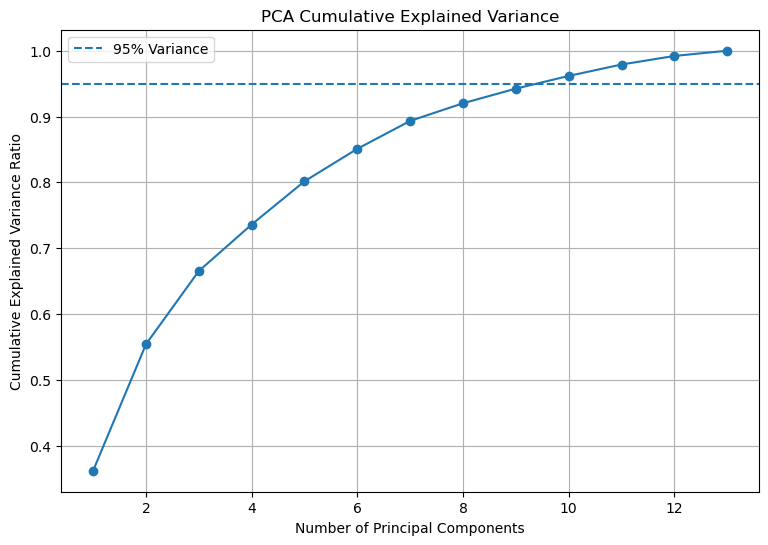

In [8]:
# Plot cumulative explained variance

plt.figure(figsize=(9, 6))

plt.plot(
    range(
        1,
        len(cumulative_variance) + 1
    ),
    cumulative_variance,
    marker="o"
)


# Add a 95% reference line

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% Variance"
)


plt.xlabel(
    "Number of Principal Components"
)

plt.ylabel(
    "Cumulative Explained Variance Ratio"
)

plt.title(
    "PCA Cumulative Explained Variance"
)

plt.legend()

plt.grid(True)

plt.show()


## 14. Find the Number of Components Required for 95% Variance

Instead of manually checking the graph, NumPy can find the first component count where cumulative explained variance reaches at least 95%.

### Important Concept

Retaining 95% variance does **not** mean retaining 95% model accuracy.

Variance and prediction accuracy are different concepts.

PCA does not directly optimize classification accuracy.


In [9]:
# Find number of components required
# to retain at least 95% variance

components_95 = (
    np.argmax(
        cumulative_variance >= 0.95
    ) + 1
)


print(
    "Number of Components Required "
    "for 95% Variance:",
    components_95
)


Number of Components Required for 95% Variance: 10


## 15. Automatic PCA Selection Using `n_components=0.95`

Scikit-Learn can automatically select enough components to retain a requested proportion of variance.

```python
PCA(n_components=0.95)
```

This means:

**Select the minimum number of Principal Components required to retain at least 95% of the variance.**

This proportion-based option is supported with the default full SVD behavior used here.


In [10]:
# Create PCA model that retains
# at least 95% of total variance

pca_95 = PCA(
    n_components=0.95
)


# Apply PCA

X_pca_95 = pca_95.fit_transform(
    X_scaled
)


# Display shape

print(
    "Before PCA:",
    X_scaled.shape
)


print(
    "After PCA:",
    X_pca_95.shape
)


print(
    "Number of Selected Components:",
    pca_95.n_components_
)


print(
    "Total Variance Retained:",
    pca_95.explained_variance_ratio_.sum()
)


Before PCA: (178, 13)
After PCA: (178, 10)
Number of Selected Components: 10
Total Variance Retained: 0.9616971684450643


## 16. PCA with Two Principal Components

Two Principal Components are commonly selected for visualization.

The original dataset has many features.

Humans cannot directly visualize a 13-dimensional feature space.

PCA can project the data into:

- PC1
- PC2

This creates a 2-dimensional representation.

### Important Warning

Using only two components for visualization may discard substantial variance.

Always inspect the explained variance ratio.


In [11]:
# Create PCA with 2 components

pca_2 = PCA(
    n_components=2
)
# Transform scaled data into 2 dimensions
X_pca_2 = pca_2.fit_transform(
    X_scaled
)
# Create DataFrame with component names
pca_df = pd.DataFrame(
    X_pca_2,
    columns=[
        "PC1",
        "PC2"
    ]
)
# Add target only for visualization
pca_df["target"] = y.values
# Display transformed data
display(pca_df.head())
# Display explained variance
print("PC1 Explained Variance:",pca_2.explained_variance_ratio_[0])
print("PC2 Explained Variance:",pca_2.explained_variance_ratio_[1])
print("Total Variance Retained:",pca_2.explained_variance_ratio_.sum())

,PC1,PC2,target
0,3.316751,-1.443463,0
1,2.209465,0.333393,0
2,2.516740,-1.031151,0
3,3.757066,-2.756372,0
4,1.008908,-0.869831,0


PC1 Explained Variance: 0.3619884809992632
PC2 Explained Variance: 0.1920749025700898
Total Variance Retained: 0.5540633835693529


## 17. Visualize PCA Data

The scatter plot displays the dataset using PC1 and PC2.

Each point represents one observation.

The target class is used only to assign labels in the visualization.

### Interpretation

If classes form separate regions in PCA space, the first two Principal Components capture variation that also helps visually distinguish the classes.

However:

**PCA does not use class labels while learning the components.**

Therefore, PCA is not a classification algorithm.


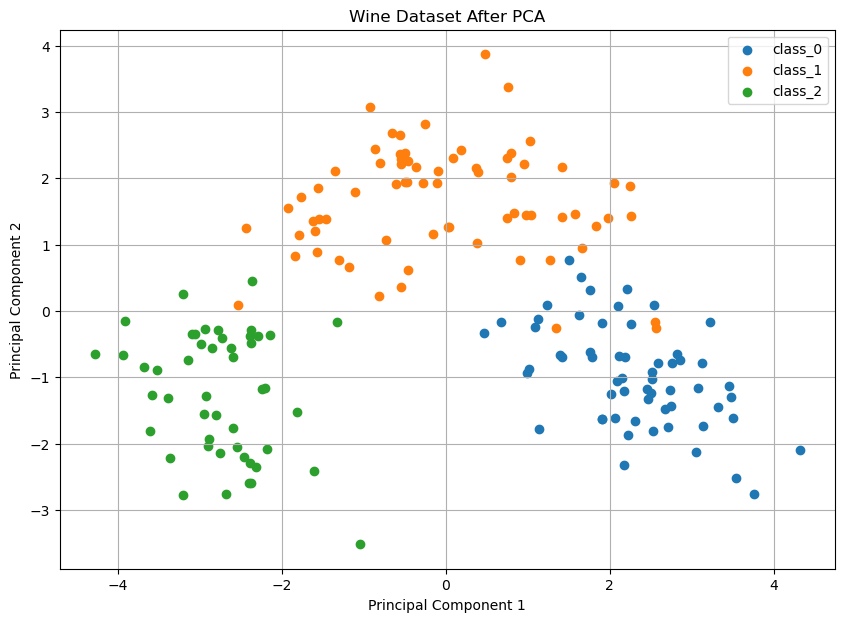

In [12]:
# Visualize the first two Principal Components
plt.figure(figsize=(10, 7))
# Plot each target class separately
for class_value in np.unique(y):
    # Select rows belonging to current class
    class_data = pca_df[
        pca_df["target"] == class_value
    ]
    # Plot current class
    plt.scatter(
        class_data["PC1"],
        class_data["PC2"],
        label=wine.target_names[class_value]
    )
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Wine Dataset After PCA")
plt.legend()
plt.grid(True)
plt.show()

## 18. PCA Components and Loadings

The `components_` attribute contains the Principal Component directions.

Each row represents one Principal Component.

Each column corresponds to one original feature.

The values are commonly called **component loadings** or component weights.

### Interpretation

A loading with a larger absolute magnitude indicates a stronger contribution of that original standardized feature to the component direction.

- Positive loading → Positive direction.
- Negative loading → Negative direction.

### Important Warning

The sign of a PCA component can be flipped without changing the PCA solution.

Therefore, another valid PCA implementation may show the same component with all signs reversed.


In [13]:
# Create a loading DataFrame

loadings = pd.DataFrame(
    pca_2.components_,
    columns=X.columns,
    index=[
        "PC1",
        "PC2"
    ]
)


# Display loadings

display(
    loadings
)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
PC1,0.144329,-0.245188,-0.002051,-0.239320,0.141992,0.394661,0.422934,-0.298533,0.313429,-0.088617,0.296715,0.376167,0.286752
PC2,-0.483652,-0.224931,-0.316069,0.010591,-0.299634,-0.065040,0.003360,-0.028779,-0.039302,-0.529996,0.279235,0.164496,-0.364903


In [14]:
# Display features with strongest
# absolute contribution to PC1

pc1_importance = (
    loadings.loc["PC1"]
    .abs()
    .sort_values(
        ascending=False
    )
)


print(
    "Features with Strongest "
    "Absolute Loadings in PC1:"
)

display(
    pc1_importance
)


Features with Strongest Absolute Loadings in PC1:


flavanoids                      0.422934
total_phenols                   0.394661
od280/od315_of_diluted_wines    0.376167
proanthocyanins                 0.313429
nonflavanoid_phenols            0.298533
hue                             0.296715
proline                         0.286752
malic_acid                      0.245188
alcalinity_of_ash               0.239320
alcohol                         0.144329
magnesium                       0.141992
color_intensity                 0.088617
ash                             0.002051
Name: PC1, dtype: float64

## 19. Visualize PCA Loadings

The following graph shows the component weights for PC1 and PC2.

### Important

PCA loadings are **not the same as supervised feature importance**.

A feature can strongly influence a Principal Component but may not be the most useful feature for predicting a target.

PCA focuses on variance in `X`.

It does not optimize prediction of `y`.


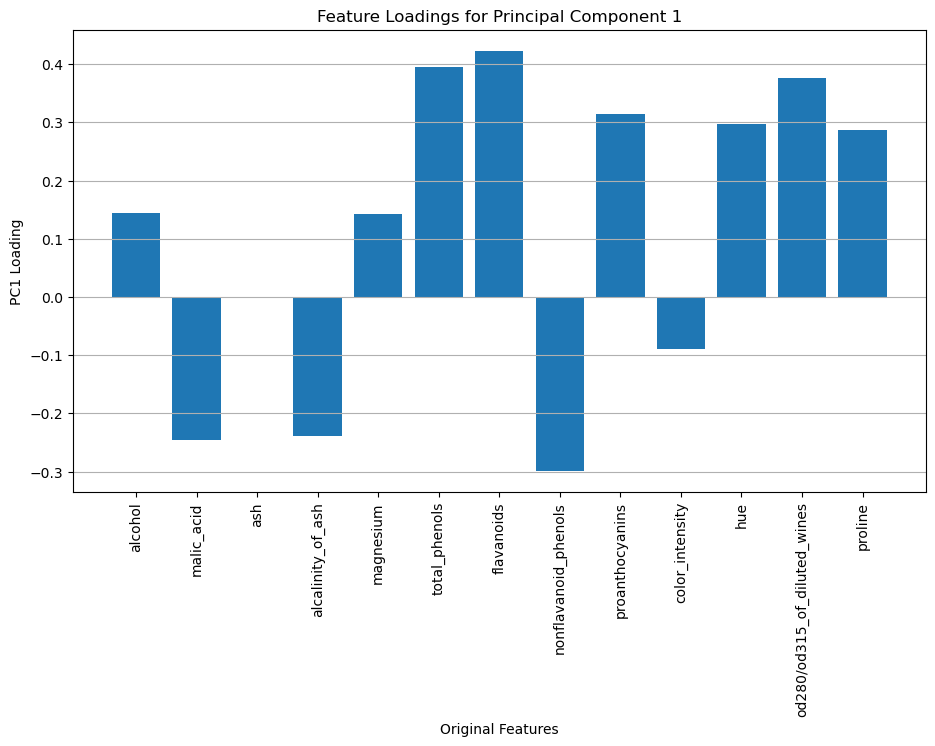

In [15]:
# Plot PC1 loadings

plt.figure(figsize=(11, 6))

plt.bar(
    loadings.columns,
    loadings.loc["PC1"]
)

plt.xlabel(
    "Original Features"
)

plt.ylabel(
    "PC1 Loading"
)

plt.title(
    "Feature Loadings for Principal Component 1"
)

plt.xticks(
    rotation=90
)

plt.grid(
    axis="y"
)

plt.show()


## 20. PCA from Scratch – Understanding the Mathematics

Scikit-Learn should normally be used for practical implementation.

The following section manually demonstrates the major PCA calculations for learning purposes.

### Steps

1. Standardize data.
2. Calculate covariance matrix.
3. Calculate eigenvalues and eigenvectors.
4. Sort eigenvalues.
5. Select top eigenvectors.
6. Project data.

### Important

Scikit-Learn PCA internally uses Singular Value Decomposition (SVD) rather than requiring users to manually construct the covariance matrix for the standard implementation.

The manual code below is for conceptual understanding.


In [16]:
# Use the already standardized data

X_manual = X_scaled


# Calculate covariance matrix

# rowvar=False means:
# Columns represent variables/features

covariance_matrix = np.cov(
    X_manual,
    rowvar=False
)


print(
    "Covariance Matrix Shape:",
    covariance_matrix.shape
)


# Display covariance matrix

print(
    covariance_matrix
)


Covariance Matrix Shape: (13, 13)
[[ 1.00564972  0.09493026  0.21273976 -0.31198788  0.27232816  0.29073446
   0.23815287 -0.15681042  0.13747022  0.549451   -0.07215255  0.07275191
   0.64735687]
 [ 0.09493026  1.00564972  0.16497228  0.29013035 -0.05488343 -0.3370606
  -0.41332866  0.29463237 -0.22199334  0.25039204 -0.56446685 -0.37079354
  -0.19309537]
 [ 0.21273976  0.16497228  1.00564972  0.44587209  0.28820583  0.12970824
   0.11572743  0.1872826   0.00970647  0.2603499  -0.07508874  0.00393333
   0.22488969]
 [-0.31198788  0.29013035  0.44587209  1.00564972 -0.0838039  -0.32292752
  -0.353355    0.36396647 -0.19844168  0.01883781 -0.27550299 -0.27833221
  -0.44308618]
 [ 0.27232816 -0.05488343  0.28820583 -0.0838039   1.00564972  0.21561254
   0.19688989 -0.25774204  0.23777643  0.20107967  0.05571118  0.06637684
   0.39557317]
 [ 0.29073446 -0.3370606   0.12970824 -0.32292752  0.21561254  1.00564972
   0.86944804 -0.45247731  0.61587304 -0.05544792  0.43613151  0.70390388
   0

### Understanding the Covariance Matrix

If the dataset has 13 features, the covariance matrix shape is:

`13 × 13`

The diagonal values represent feature variances.

The off-diagonal values represent covariance between pairs of features.

Because the data was standardized, the diagonal values are close to 1, with small differences depending on the covariance calculation convention.


In [17]:
# Calculate eigenvalues and eigenvectors

# eigh is suitable for symmetric matrices
# such as a covariance matrix

eigenvalues, eigenvectors = np.linalg.eigh(
    covariance_matrix
)


print(
    "Eigenvalues:"
)

print(
    eigenvalues
)


print(
    "\nEigenvector Matrix Shape:"
)

print(
    eigenvectors.shape
)


Eigenvalues:
[0.10396199 0.16972374 0.22706428 0.25232001 0.29051203 0.35046627
 0.55414147 0.64528221 0.85804868 0.92416587 1.45424187 2.51108093
 4.73243698]

Eigenvector Matrix Shape:
(13, 13)


### Eigenvalues and Eigenvectors

In PCA:

- Eigenvectors represent directions.
- Eigenvalues represent variance associated with those directions.

The Principal Components must be ordered from the highest variance to the lowest variance.

`np.linalg.eigh()` returns eigenvalues in ascending order.

Therefore, we sort them in descending order.


In [18]:
# Get indices that sort eigenvalues
# from largest to smallest

sorted_indices = np.argsort(
    eigenvalues
)[::-1]


# Sort eigenvalues

sorted_eigenvalues = eigenvalues[
    sorted_indices
]


# Sort corresponding eigenvectors

sorted_eigenvectors = eigenvectors[
    :,
    sorted_indices
]


print(
    "Sorted Eigenvalues:"
)

print(
    sorted_eigenvalues
)


Sorted Eigenvalues:
[4.73243698 2.51108093 1.45424187 0.92416587 0.85804868 0.64528221
 0.55414147 0.35046627 0.29051203 0.25232001 0.22706428 0.16972374
 0.10396199]


In [19]:
# Select first two eigenvectors

top_2_eigenvectors = (
    sorted_eigenvectors[:, :2]
)


# Project standardized data
# onto the first two PCA directions

X_manual_pca = (
    X_manual @
    top_2_eigenvectors
)


print(
    "Manual PCA Shape:",
    X_manual_pca.shape
)


print(
    "\nFirst 5 PCA Rows:"
)

print(
    X_manual_pca[:5]
)


Manual PCA Shape: (178, 2)

First 5 PCA Rows:
[[-3.31675081 -1.44346263]
 [-2.20946492  0.33339289]
 [-2.51674015 -1.0311513 ]
 [-3.75706561 -2.75637191]
 [-1.00890849 -0.86983082]]


## 21. Manual PCA vs Scikit-Learn PCA

The manual PCA values may have opposite signs compared with Scikit-Learn.

Example:

`Manual PC1 = +3.31`

`Scikit-Learn PC1 = -3.31`

This does not necessarily indicate an error.

### Why?

Eigenvector direction has sign ambiguity.

If $v$ is an eigenvector, then $-v$ is also a valid eigenvector.

The represented axis is the same, but its direction is reversed.

### Practical Recommendation

Use `sklearn.decomposition.PCA` for real Machine Learning projects.

Use manual PCA calculations to understand the mathematical process.


## 22. PCA Before Machine Learning

PCA can be used as a preprocessing step before a Machine Learning algorithm.

Correct workflow:

`Training Data → Scaling → PCA → Model Training`

Testing workflow:

`Testing Data → Same Scaler → Same PCA → Model Prediction`

### Very Important: Data Leakage

Do not fit StandardScaler or PCA using the complete dataset before train-test splitting when evaluating a predictive model.

Incorrect:

`Complete Data → Scale → PCA → Train-Test Split`

Correct:

`Train-Test Split → Fit Scaler on Training Data → Fit PCA on Training Data`

The test data must remain unseen while preprocessing parameters are learned.


In [20]:
# Split original feature data FIRST

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Create scaler

scaler_model = StandardScaler()


# Fit scaler ONLY on training data

X_train_scaled = (
    scaler_model.fit_transform(
        X_train
    )
)


# Use the SAME scaler for test data

X_test_scaled = (
    scaler_model.transform(
        X_test
    )
)


# Create PCA
# Retain at least 95% variance

pca_model = PCA(
    n_components=0.95
)


# Fit PCA ONLY on training data

X_train_pca = (
    pca_model.fit_transform(
        X_train_scaled
    )
)


# Use SAME PCA transformation
# for testing data

X_test_pca = (
    pca_model.transform(
        X_test_scaled
    )
)


print(
    "Original Training Shape:",
    X_train.shape
)


print(
    "PCA Training Shape:",
    X_train_pca.shape
)


print(
    "Original Testing Shape:",
    X_test.shape
)


print(
    "PCA Testing Shape:",
    X_test_pca.shape
)


print(
    "Variance Retained:",
    pca_model.explained_variance_ratio_.sum()
)


Original Training Shape: (142, 13)
PCA Training Shape: (142, 10)
Original Testing Shape: (36, 13)
PCA Testing Shape: (36, 10)
Variance Retained: 0.9624355601767977


## 23. Train Logistic Regression After PCA

After PCA, the Principal Components become the input features for the classifier.

The classifier does not directly receive the original Wine features.

It receives:

`PC1, PC2, PC3, ...`

selected by PCA.

### Important

PCA is preprocessing.

Logistic Regression is the classification algorithm.


In [21]:
# Create Logistic Regression model

model = LogisticRegression(
    max_iter=1000
)


# Train model using PCA-transformed data

model.fit(
    X_train_pca,
    y_train
)


# Make predictions

y_pred = model.predict(
    X_test_pca
)


# Calculate accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)


print(
    "Accuracy After PCA:",
    accuracy
)


# Display confusion matrix

print(
    "\nConfusion Matrix:"
)

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)


# Display classification report

print(
    "\nClassification Report:"
)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=wine.target_names
    )
)


Accuracy After PCA: 0.9722222222222222

Confusion Matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



## 24. Compare Model Without PCA and With PCA

PCA should not be assumed to improve accuracy.

We compare:

1. Logistic Regression using scaled original features.
2. Logistic Regression using PCA features.

### Evaluation Questions

- Did the number of features reduce?
- Did training become simpler?
- How much variance was retained?
- Did accuracy increase or decrease?
- Is the accuracy difference acceptable for the dimensionality reduction obtained?

The final decision should be based on the complete project requirement.


In [22]:
# -------------------------------------------------
# MODEL WITHOUT PCA
# -------------------------------------------------

model_without_pca = LogisticRegression(
    max_iter=1000
)


model_without_pca.fit(
    X_train_scaled,
    y_train
)


pred_without_pca = (
    model_without_pca.predict(
        X_test_scaled
    )
)


accuracy_without_pca = accuracy_score(
    y_test,
    pred_without_pca
)


# -------------------------------------------------
# MODEL WITH PCA
# -------------------------------------------------

accuracy_with_pca = accuracy


# -------------------------------------------------
# COMPARISON
# -------------------------------------------------

print(
    "Number of Original Features:",
    X_train_scaled.shape[1]
)


print(
    "Number of PCA Components:",
    X_train_pca.shape[1]
)


print(
    "\nAccuracy Without PCA:",
    accuracy_without_pca
)


print(
    "Accuracy With PCA:",
    accuracy_with_pca
)


Number of Original Features: 13
Number of PCA Components: 10

Accuracy Without PCA: 0.9722222222222222
Accuracy With PCA: 0.9722222222222222


## 25. PCA Using a Pipeline

A Pipeline is a clean and safer way to combine:

1. StandardScaler
2. PCA
3. Machine Learning model

### Advantages

- Reduces preprocessing mistakes.
- Applies steps in the correct order.
- Helps prevent inconsistent train and test transformations.
- Works well with cross-validation and hyperparameter tuning.


In [23]:
# Import Pipeline

from sklearn.pipeline import Pipeline


# Create complete Machine Learning Pipeline

pca_pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "pca",
        PCA(
            n_components=0.95
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000
        )
    )
])


# Train complete pipeline

pca_pipeline.fit(
    X_train,
    y_train
)


# Make predictions

pipeline_predictions = (
    pca_pipeline.predict(
        X_test
    )
)


# Evaluate

pipeline_accuracy = accuracy_score(
    y_test,
    pipeline_predictions
)


print(
    "Pipeline Accuracy:",
    pipeline_accuracy
)


# Access PCA step from pipeline

selected_components = (
    pca_pipeline
    .named_steps["pca"]
    .n_components_
)


print(
    "Selected PCA Components:",
    selected_components
)


Pipeline Accuracy: 0.9722222222222222
Selected PCA Components: 10


## 26. Important PCA Attributes in Scikit-Learn

### `components_`

Contains Principal Component directions or loadings.

### `explained_variance_`

Contains the variance associated with each selected Principal Component.

### `explained_variance_ratio_`

Contains the proportion of total variance explained by each component.

### `n_components_`

Contains the number of components selected after fitting.

### `mean_`

Contains the feature-wise mean estimated by PCA for centering its input.

### `singular_values_`

Contains singular values corresponding to the selected components.

### Important Methods

- `fit()` → Learn PCA directions.
- `transform()` → Project data onto learned components.
- `fit_transform()` → Learn PCA and transform the same data.
- `inverse_transform()` → Reconstruct an approximation in the original PCA input feature space.


In [24]:
# Inspect important PCA attributes

print(
    "Number of Components:",
    pca_model.n_components_
)


print(
    "\nExplained Variance:"
)

print(
    pca_model.explained_variance_
)


print(
    "\nExplained Variance Ratio:"
)

print(
    pca_model.explained_variance_ratio_
)


print(
    "\nPCA Component Matrix Shape:"
)

print(
    pca_model.components_.shape
)


print(
    "\nPCA Mean Shape:"
)

print(
    pca_model.mean_.shape
)


Number of Components: 10

Explained Variance:
[4.68597338 2.52295457 1.44273869 0.95210078 0.88004699 0.67188411
 0.57310085 0.32741663 0.29842753 0.24575395]

Explained Variance Ratio:
[0.35792104 0.19270671 0.11019835 0.07272276 0.06721919 0.05131943
 0.04377423 0.02500853 0.0227943  0.01877102]

PCA Component Matrix Shape:
(10, 13)

PCA Mean Shape:
(13,)


## 27. PCA Inverse Transform

PCA can approximately reconstruct data from the reduced component space.

Process:

`Original Scaled Data → PCA Components → Reconstructed Scaled Data`

If components were removed, the reconstruction is usually not exactly equal to the original data.

Why?

Some variance was discarded during dimensionality reduction.

### Important

`inverse_transform()` reconstructs values in the feature space supplied to PCA.

Because PCA received standardized data here, the PCA inverse result is still in standardized feature space.

The scaler must also be reversed to return to original measurement units.


In [25]:
# Take first 5 test samples in PCA space

sample_pca = X_test_pca[:5]


# Reconstruct standardized feature values

reconstructed_scaled = (
    pca_model.inverse_transform(
        sample_pca
    )
)


# Convert standardized values
# back to original measurement scale

reconstructed_original = (
    scaler_model.inverse_transform(
        reconstructed_scaled
    )
)


print(
    "Reconstructed Data Shape:",
    reconstructed_original.shape
)


# Display reconstructed values

reconstructed_df = pd.DataFrame(
    reconstructed_original,
    columns=X.columns
)


display(
    reconstructed_df
)


Reconstructed Data Shape: (5, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.273402,1.929487,2.345210,17.418899,106.214290,2.768440,3.174647,0.235485,2.461662,5.490191,1.183940,3.490121,1447.996872
1,12.297019,1.438452,2.216609,17.709111,86.292813,1.828588,0.930442,0.608879,1.139548,6.616786,0.811799,1.675360,639.010087
2,13.834789,1.952357,2.779557,19.709213,106.486297,3.005203,3.140134,0.364951,1.727898,4.351992,1.257550,3.202403,946.873908
3,11.830379,1.895638,3.306184,27.860157,114.662240,3.897488,3.519009,0.427045,2.119739,4.419702,0.916932,3.416644,497.333230
4,13.739149,1.156908,1.941545,17.709549,94.550353,2.024615,1.684698,0.326585,0.767722,3.755614,1.205724,2.626779,599.630133


## 28. Advantages of PCA

- Reduces dimensionality.
- Can reduce redundant correlated information.
- Can reduce storage and computational requirements.
- Supports 2D and 3D visualization.
- Produces orthogonal Principal Components.
- Can improve optimization for some models.
- Can reduce some effects of high-dimensional feature spaces.

---

## 29. Limitations of PCA

- Principal Components may be difficult to interpret.
- PCA is a linear transformation.
- PCA is sensitive to feature scaling.
- Important low-variance information may be removed.
- PCA does not use target labels.
- Reduced dimensions do not guarantee better model accuracy.
- Outliers can strongly affect variance and PCA directions.
- Original feature meaning is not directly preserved in each component.

---

## 30. When to Use PCA

Consider PCA when:

- The dataset has many numerical features.
- Features are highly correlated.
- Dimensionality reduction is required.
- Visualization of high-dimensional data is required.
- Computational reduction is useful.
- A downstream model benefits from a compact representation.

## 31. When PCA May Not Be Suitable

PCA may not be the best choice when:

- Original feature interpretability is critical.
- The important structure is strongly non-linear.
- Features are mainly categorical without a suitable numerical representation.
- Low-variance features contain important predictive information.
- The dataset already contains very few features.


## 32. Common PCA Mistakes

### Mistake 1: Applying PCA Before Scaling Without Checking Feature Units

Features with larger numerical scales can dominate variance.

### Mistake 2: Fitting PCA on Complete Data Before Train-Test Split

This causes data leakage during model evaluation.

### Mistake 3: Assuming PC1 is the Most Important Feature

PC1 is a Principal Component, not an original feature.

### Mistake 4: Saying PCA Selects Features

PCA generally **creates new features**.

It is a **feature extraction technique**, not ordinary feature selection.

### Mistake 5: Assuming 95% Variance Means 95% Accuracy

Explained variance and model accuracy are different.

### Mistake 6: Using Target Labels to Fit Standard PCA

Standard PCA learns from input feature variation and does not use `y`.

### Mistake 7: Assuming PCA Always Improves Accuracy

PCA can increase, decrease, or leave model performance approximately unchanged.

### Mistake 8: Interpreting Loading Sign Too Rigidly

Component signs can be reversed while representing the same PCA axis.


## 33. PCA vs Feature Selection

### Feature Selection

Selects some original features.

Example:

`X1, X2, X3, X4 → X1, X3`

Original feature meaning is retained.

### PCA

Creates new features.

Example:

`X1, X2, X3, X4 → PC1, PC2`

The Principal Components are combinations of original features.

### Key Difference

**Feature Selection = Keep selected original features**

**PCA = Create new transformed features**


## 34. Important Interview Questions

**Q1. What is PCA?**  
PCA is an unsupervised linear dimensionality reduction technique that transforms original features into orthogonal Principal Components ordered by explained variance.

**Q2. What is the objective of PCA?**  
To reduce dimensionality while preserving as much variance as possible.

**Q3. Is PCA supervised or unsupervised?**  
Unsupervised.

**Q4. Does PCA use the target variable?**  
No. Standard PCA learns from input features.

**Q5. What is a Principal Component?**  
A new direction formed as a linear combination of original features.

**Q6. What is PC1?**  
The Principal Component explaining the maximum variance.

**Q7. What is PC2?**  
The orthogonal direction explaining the highest remaining variance after PC1.

**Q8. Why is scaling important before PCA?**  
PCA is variance-based, so large-scale features may dominate the components.

**Q9. What is Explained Variance Ratio?**  
The proportion of total variance explained by a Principal Component.

**Q10. What is Cumulative Explained Variance?**  
The total variance explained by the first several components together.

**Q11. What are eigenvectors in PCA?**  
Directions associated with the covariance structure of the data.

**Q12. What are eigenvalues in PCA?**  
Values indicating the variance associated with eigenvector directions.

**Q13. Is PCA feature selection?**  
No. PCA is mainly a feature extraction technique.

**Q14. Does PCA always improve accuracy?**  
No.

**Q15. Can PCA be used for visualization?**  
Yes. Data can be projected to two or three Principal Components.

**Q16. What are PCA loadings?**  
Weights describing how original features contribute to Principal Component directions.

**Q17. Why are PCA components orthogonal?**  
PCA constructs mutually perpendicular component directions.

**Q18. What is data leakage in PCA?**  
Learning PCA directions using test data before model evaluation.

**Q19. What is `components_`?**  
The learned Principal Component directions.

**Q20. What is `explained_variance_ratio_`?**  
The proportion of total variance explained by each selected component.

**Q21. What does `n_components=0.95` mean?**  
Select enough components to retain at least 95% of total variance.

**Q22. What is the difference between PCA and feature selection?**  
Feature selection retains original features; PCA creates transformed components.

**Q23. Is PCA linear or non-linear?**  
Standard PCA is linear.

**Q24. Can PCA handle categorical features directly?**  
Standard PCA expects numerical input.

**Q25. Why can PCA signs differ between implementations?**  
Eigenvector and component directions have sign ambiguity.


## 35. Final Revision

### PCA One-Line Flow

`Original Features → Scale Data → Find Maximum Variance Directions → Select Principal Components → Project Data → Reduced Dataset`

### Most Important Points

- **PCA** = Principal Component Analysis
- **Type** = Unsupervised dimensionality reduction
- **Objective** = Preserve maximum variance
- **PC1** = Maximum variance direction
- **PC2** = Next highest orthogonal variance direction
- **Principal Components** = New transformed features
- **Variance** = Data spread
- **Covariance** = How variables vary together
- **Eigenvector** = Direction
- **Eigenvalue** = Variance associated with direction
- **Explained Variance Ratio** = Variance proportion explained by a component
- **Cumulative Variance** = Combined variance retained
- **Scaling** = Commonly important before PCA
- **PCA is not Feature Selection**
- **PCA does not use target labels**
- **PCA does not guarantee better accuracy**
- **Fit preprocessing only on training data during model evaluation**

### Simple Explanation

**PCA looks for new directions in the data where the observations vary the most. It keeps the most informative variance directions and can remove lower-variance directions to reduce the number of dimensions.**
